In [8]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

def Z1(x,w,p): return p.k1(x)/(1j*w)+p.c1(x)+1j*w*p.m1(x)
def Z2(x,w,p): return p.k2(x)/(1j*w)+p.c2(x)+1j*w*p.m2(x)
def Z3(x,w,p): return p.k3(x)/(1j*w)+p.c3(x)
def Z4(x,w,p): return p.k4(x)/(1j*w)+p.c4(x)

def Z1_s(xt,p): return ct.tf([p.m1(xt), p.c1(xt), p.k1(xt)], [1,0])
def Z2_s(xt,p): return ct.tf([p.m2(xt), p.c2(xt), p.k2(xt)], [1,0])
def Z3_s(xt,p): return ct.tf([p.c3(xt), p.k3(xt)], [1,0])
def Z4_s(xt,p): return ct.tf([p.c4(xt), p.k4(xt)], [1,0])

bloques = [
    ("Z1", Z1, Z1_s, "k1","c1","m1", "impedancia del organo de Corti"),
    ("Z2", Z2, Z2_s, "k2","c2","m2", "impedancia de la membrana tectorial"),
    ("Z3", Z3, Z3_s, "k3","c3",None, "acoplo organo de Corti / membrana tectorial"),
    ("Z4", Z4, Z4_s, "k4","c4",None, "fase del elemento activo"),
]
xs_estudio = [0.1, 0.3, 0.5, 0.7, 0.9]

In [9]:
print(f"{'bloque':>6} {'x/L':>6} {'orden(num,den)':>15} {'tipo':>8} {'wn o f_esq (Hz)':>16} {'zeta':>8} {'resuena?':>10}")
resultados_tabla = []
for nombre, Zfun, Zsfun, nk, nc, nm, _ in bloques:
    for xL in xs_estudio:
        xt = xL * p.L
        Zs = Zsfun(xt, p)
        num_ord = len(Zs.num[0][0]) - 1
        den_ord = len(Zs.den[0][0]) - 1
        if nm:
            k,c,m = getattr(p,nk)(xt), getattr(p,nc)(xt), getattr(p,nm)(xt)
            wn = np.sqrt(k/m); zeta = c/(2*np.sqrt(k*m))
            resuena = "si" if zeta < 1 else "no"
            print(f"{nombre:>6} {xL:6.1f} {f'({num_ord},{den_ord})':>15} {'tipo-1':>8} {wn/(2*np.pi):16.1f} {zeta:8.3f} {resuena:>10}")
            resultados_tabla.append((nombre,xL,wn/(2*np.pi),zeta,resuena))
        else:
            k,c = getattr(p,nk)(xt), getattr(p,nc)(xt)
            fc = (k/c)/(2*np.pi)
            print(f"{nombre:>6} {xL:6.1f} {f'({num_ord},{den_ord})':>15} {'tipo-1':>8} {fc:16.1f} {'N/A':>8} {'nunca (sin masa)':>10}")
            resultados_tabla.append((nombre,xL,fc,None,"nunca (sin masa)"))
    print()

bloque    x/L  orden(num,den)     tipo  wn o f_esq (Hz)     zeta   resuena?
    Z1    0.1           (2,1)   tipo-1          58453.2    0.422         si
    Z1    0.3           (2,1)   tipo-1          21503.7    0.438         si
    Z1    0.5           (2,1)   tipo-1           7910.8    0.480         si
    Z1    0.7           (2,1)   tipo-1           2910.2    0.595         si
    Z1    0.9           (2,1)   tipo-1           1070.6    0.908         si

    Z2    0.1           (2,1)   tipo-1           9588.2    0.075         si
    Z2    0.3           (2,1)   tipo-1           2485.6    0.058         si
    Z2    0.5           (2,1)   tipo-1            644.4    0.045         si
    Z2    0.7           (2,1)   tipo-1            167.0    0.035         si
    Z2    0.9           (2,1)   tipo-1             43.3    0.027         si

    Z3    0.1           (1,1)   tipo-1         357564.6      N/A nunca (sin masa)
    Z3    0.3           (1,1)   tipo-1          72191.1      N/A nunca (sin masa

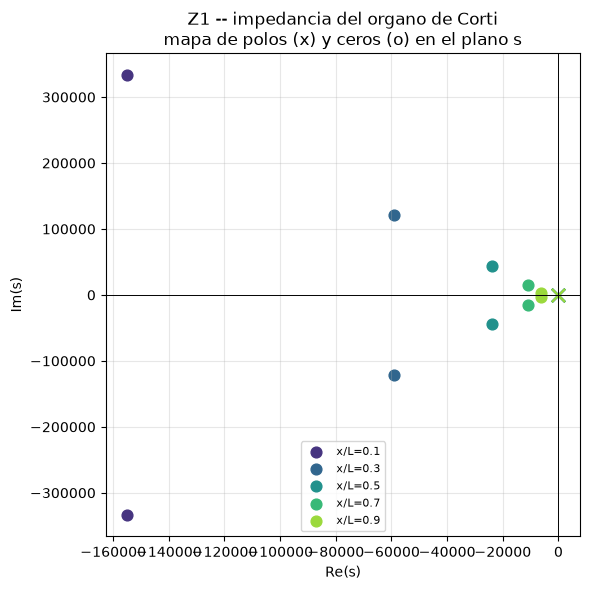

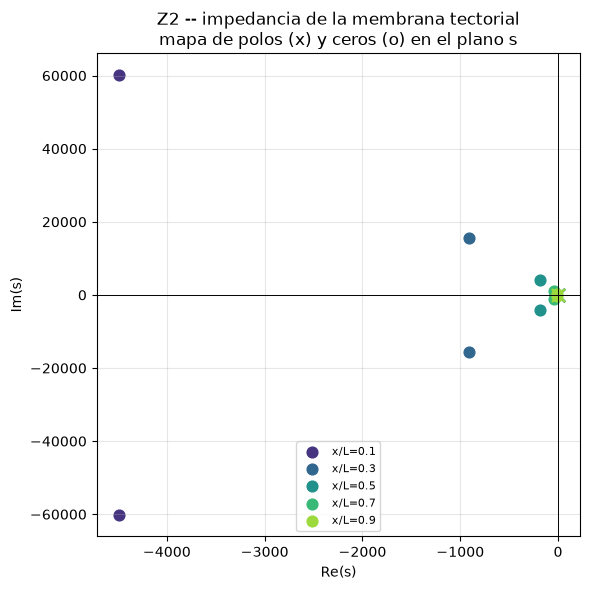

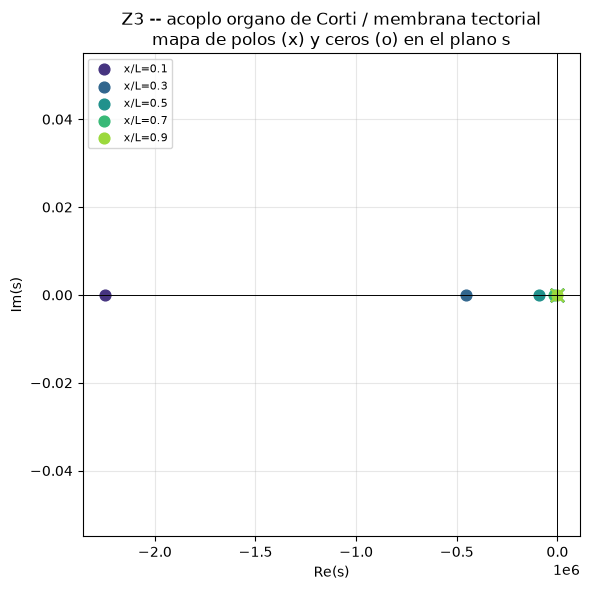

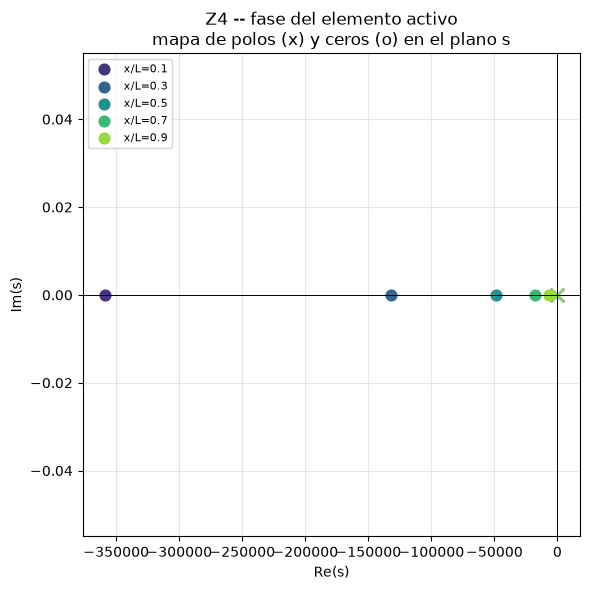

In [15]:
colores_x = plt.cm.viridis(np.linspace(0.15, 0.85, len(xs_estudio)))

for nombre, Zfun, Zsfun, nk, nc, nm, significado in bloques:
    fig, ax = plt.subplots(figsize=(6,6))
    for xL, color in zip(xs_estudio, colores_x):
        xt = xL * p.L
        Zs = Zsfun(xt, p)
        polos = ct.poles(Zs); ceros = ct.zeros(Zs)
        ax.scatter(polos.real, polos.imag, marker='x', s=90, color=color)
        ax.scatter(ceros.real, ceros.imag, marker='o', s=60, color=color, label=f"x/L={xL}")
    ax.axvline(0, color='k', linewidth=0.7); ax.axhline(0, color='k', linewidth=0.7)
    ax.set_xlabel('Re(s)'); ax.set_ylabel('Im(s)')
    ax.set_title(f"{nombre} -- {significado}\nmapa de polos (x) y ceros (o) en el plano s")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"pzmap_{nombre}.png", dpi=150, bbox_inches='tight')
    plt.show()

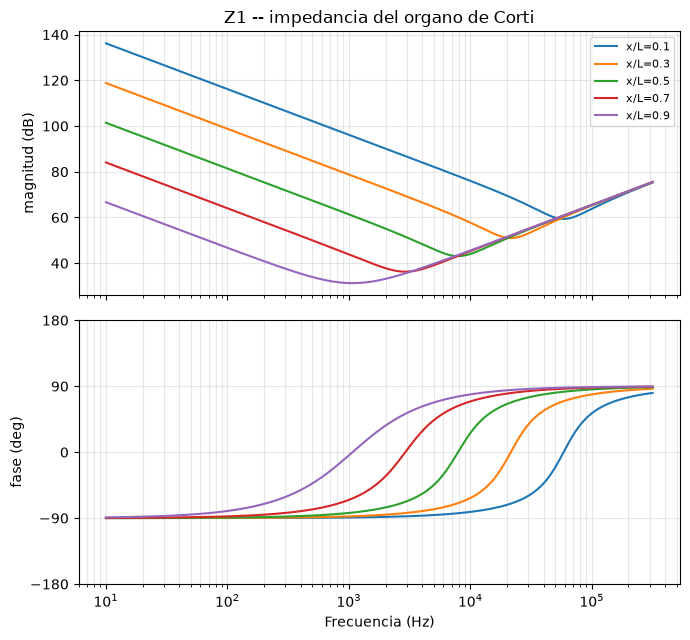

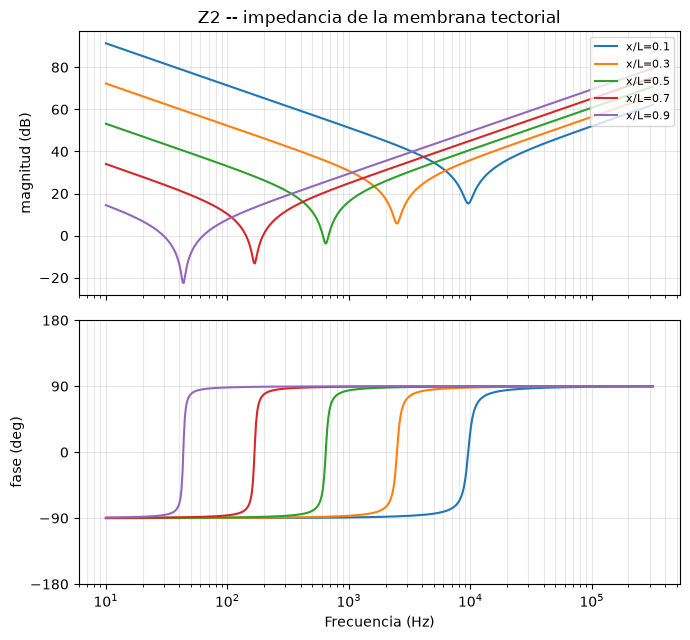

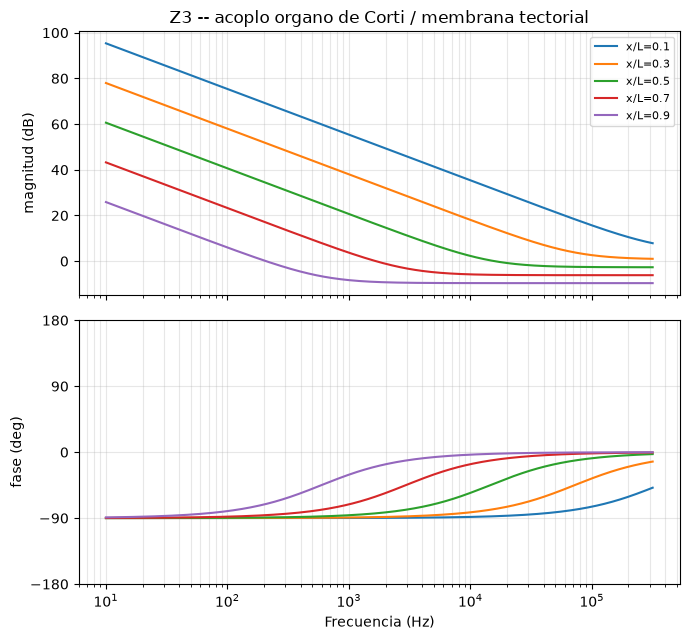

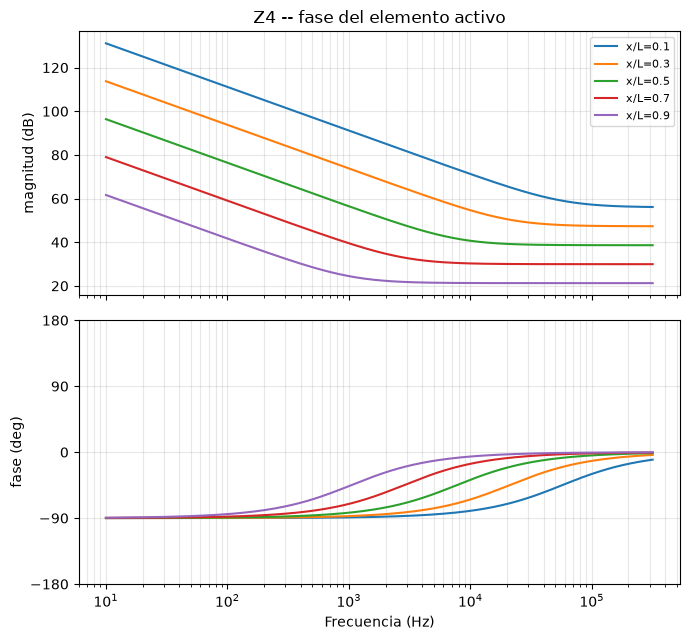

In [16]:
freqs = np.logspace(1, 5.5, 500)

for nombre, Zfun, Zsfun, nk, nc, nm, significado in bloques:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True)
    for xL in xs_estudio:
        xt = xL * p.L
        vals = np.array([Zfun(xt, 2*np.pi*f, p) for f in freqs])
        ax1.semilogx(freqs, 20*np.log10(np.abs(vals)), label=f"x/L={xL}")
        ax2.semilogx(freqs, np.angle(vals, deg=True), label=f"x/L={xL}")
    ax1.set_title(f"{nombre} -- {significado}")
    ax1.set_ylabel("magnitud (dB)"); ax1.legend(loc='upper right', fontsize=8); ax1.grid(True, which='both', alpha=0.3)
    ax2.set_ylabel("fase (deg)"); ax2.set_ylim(-180,180); ax2.set_yticks([-180,-90,0,90,180])
    ax2.set_xlabel("Frecuencia (Hz)"); ax2.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"bode_{nombre}.png", dpi=150, bbox_inches='tight')
    plt.show()